# Lost & Found Item Classifier
### A transfer-learning image classifier — starter project for MIZERO

This notebook trains a model to recognize common **lost-item categories** (phone, ID card, keys, bag, wallet, etc.) from photos.

Instead of training from scratch (which needs tens of thousands of images), this uses **transfer learning**: we take a model already trained on millions of images (MobileNetV2) and fine-tune just its final layers on your own smaller dataset. This is the standard real-world approach and works well with only 50-150 photos per category.

**What you'll need before running this:**
- Photos organized into folders, one folder per category (see structure below)
- Python packages: `tensorflow`, `numpy`, `matplotlib`, `pillow`

Install with:
```
pip install tensorflow numpy matplotlib pillow
```


## Step 1 — Organize your dataset

Create a folder structure like this next to this notebook:

```
dataset/
  train/
    phone/
      img001.jpg
      img002.jpg
      ...
    id_card/
      ...
    keys/
      ...
    wallet/
      ...
    bag/
      ...
  val/
    phone/
      ...
    id_card/
      ...
    keys/
      ...
    wallet/
      ...
    bag/
      ...
```

- Aim for **50-150 photos per category** in `train/`, and **10-20 per category** in `val/` (validation, used to check accuracy during training).
- Take photos from different angles, lighting, and backgrounds — this matters more than sheer quantity for a small dataset.
- You can start with just 3 categories (e.g. phone, ID card, keys) and add more later — the code below adapts automatically to however many folders you create.


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

# Path to your dataset — change this if your folder is elsewhere
DATA_DIR = "dataset"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")

IMG_SIZE = (224, 224)   # required input size for MobileNetV2
BATCH_SIZE = 16

print("Categories found:", sorted(os.listdir(TRAIN_DIR)) if os.path.exists(TRAIN_DIR) else "dataset/train not found yet — create it first")


Categories found: ['Bottle', 'Calculator', 'Charger', 'Key', 'Umbrella']


## Step 2 — Load the dataset

In [2]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

# Speed up data loading
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 3501 files belonging to 5 classes.


2026-09-07 11:31:52.060636: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-09-07 11:31:52.060859: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-09-07 11:31:52.060868: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-09-07 11:31:52.061030: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-07 11:31:52.061041: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 846 files belonging to 5 classes.
Classes: ['Bottle', 'Calculator', 'Charger', 'Key', 'Umbrella']


## Step 3 — Preview a few images (sanity check)

2026-09-07 11:32:06.156929: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2026-09-07 11:32:06.259426: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


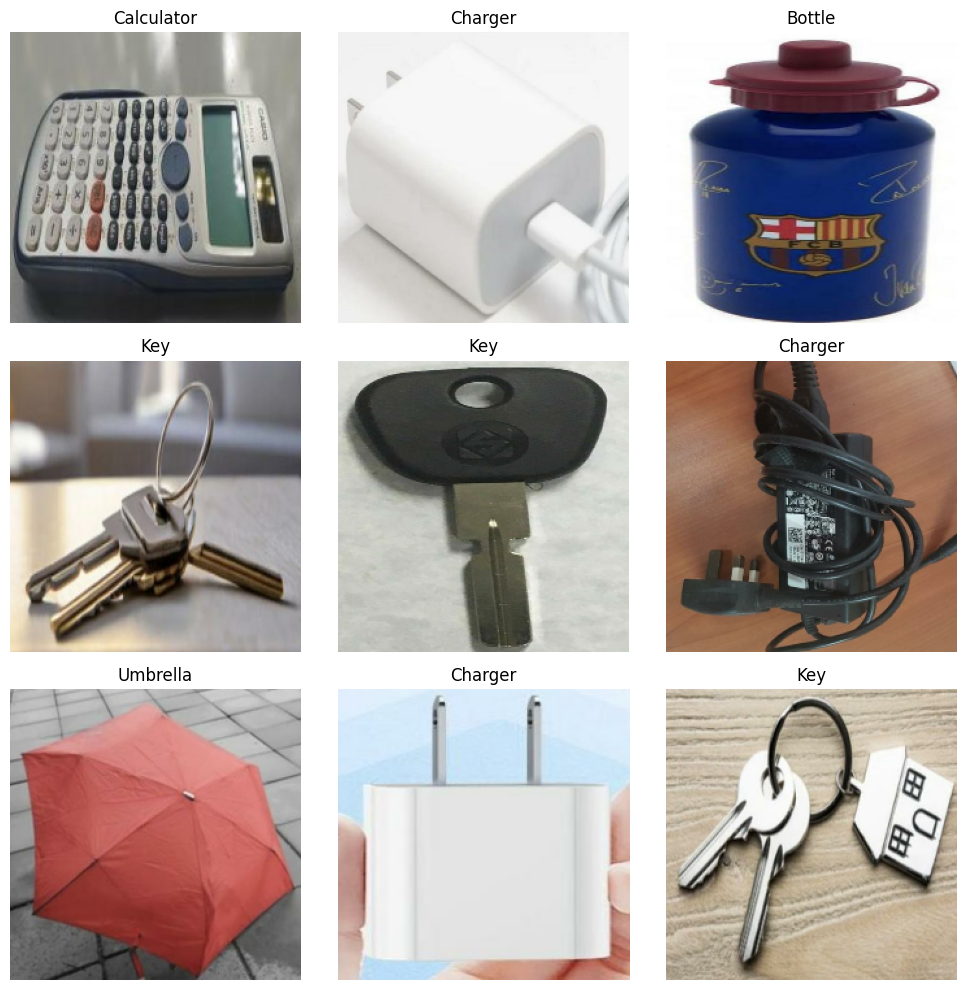

In [3]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()


## Step 4 — Build the model (transfer learning)

We load MobileNetV2 pretrained on ImageNet, freeze its weights (so we don't destroy what it already learned), and add a small classification head on top for our specific categories.


In [4]:
# Data augmentation: helps the model generalize with a small dataset
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Preprocessing expected by MobileNetV2
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = False  # freeze the pretrained base

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 61s 6us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Step 5 — Train

In [5]:
EPOCHS = 15

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)


Epoch 1/15


2026-09-07 11:33:46.484500: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 65ms/step - accuracy: 0.8580 - loss: 0.4092 - val_accuracy: 0.9811 - val_loss: 0.0941
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 57ms/step - accuracy: 0.9466 - loss: 0.1524 - val_accuracy: 0.9846 - val_loss: 0.0664
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9629 - loss: 0.1120 - val_accuracy: 0.9823 - val_loss: 0.0592
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9637 - loss: 0.1038 - val_accuracy: 0.9752 - val_loss: 0.0686
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.9709 - loss: 0.0888 - val_accuracy: 0.9835 - val_loss: 0.0576
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9694 - loss: 0.0845 - val_accuracy: 0.9846 - val_loss: 0.0491
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9726 - loss: 0.0786 - val_accuracy: 0.9823 - val_loss: 0.0602
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.9737 - loss: 0.0735 - val_accurac

## Step 6 — Check training curves

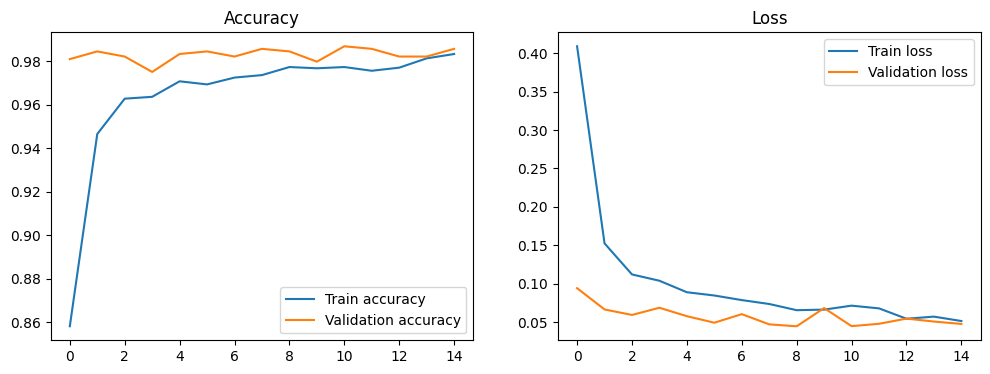

In [6]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Train accuracy")
plt.plot(epochs_range, val_acc, label="Validation accuracy")
plt.legend()
plt.title("Accuracy")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Train loss")
plt.plot(epochs_range, val_loss, label="Validation loss")
plt.legend()
plt.title("Loss")

plt.show()


## Step 7 — Optional: fine-tune deeper layers

If accuracy plateaus and you want to squeeze out more, unfreeze the top layers of MobileNetV2 and train a bit more with a very low learning rate. Skip this step if your Step 5 accuracy already looks good (85%+ on validation).


In [7]:
base_model.trainable = True

# Freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # much smaller LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 10
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
)


Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 27s 96ms/step - accuracy: 0.8620 - loss: 0.4287 - val_accuracy: 0.9787 - val_loss: 0.0690
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.9346 - loss: 0.1875 - val_accuracy: 0.9823 - val_loss: 0.0571
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.9497 - loss: 0.1447 - val_accuracy: 0.9823 - val_loss: 0.0545
Epoch 4/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9612 - loss: 0.1101 - val_accuracy: 0.9858 - val_loss: 0.0549
Epoch 5/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9569 - loss: 0.1204 - val_accuracy: 0.9870 - val_loss: 0.0528
Epoch 6/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 18s 84ms/step - accuracy: 0.9660 - loss: 0.0931 - val_accuracy: 0.9858 - val_loss: 0.0527
Epoch 7/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 85ms/step - accuracy: 0.9686 - loss: 0.0817 - val_accuracy: 0.9870 - val_loss: 0.0508
Epoch 8/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 19s 86ms/step - accuracy: 0.9700 - loss: 0.0812 - 

## Step 8 — Test on a single new photo

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


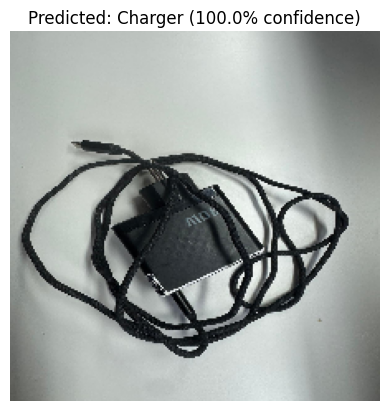

('Charger', 99.97876286506653)

In [16]:
def predict_image(img_path):
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)  # add batch dimension

    predictions = model.predict(img_array)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = 100 * np.max(predictions[0])

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Predicted: {predicted_class} ({confidence:.1f}% confidence)")
    plt.show()

    return predicted_class, confidence
predict_image("my_test_keyjpeg.jpeg")

# Example usage — replace with a real path to a test photo:
# predict_image("test_photos/my_phone.jpg")


## Step 9 — Save the model

Save it so you can load it later without retraining — this is the file you'd wire into MIZERO's backend.


In [17]:
model.save("lost_item_classifier.keras")
print("Model saved as lost_item_classifier.keras")

# To load it again later:
# model = tf.keras.models.load_model("lost_item_classifier.keras")


Model saved as lost_item_classifier.keras


## Next steps for MIZERO integration

- Wrap `predict_image()` (or the underlying model) in an API endpoint (e.g. a FastAPI or Next.js API route) that accepts an uploaded photo and returns the predicted category.
- When someone reports a lost item with a photo, run it through this classifier to auto-tag the category — this feeds directly into your matching logic.
- As you collect more real reports through MIZERO, periodically retrain the model on that real data to improve accuracy over time.
- Consider adding more categories as real usage patterns emerge (e.g. "student ID", "umbrella", "laptop bag") — categories specific to your actual user base will matter more than generic ones.
